# 1. Compilación del corpus y procesamiento léxico

Carga de los JSON ya generados por `scripts/00_descarga_datos.py` para cada subreddit, y análisis exploratorio (EDA) del corpus: estrategia de selección, estadísticas y observaciones.

In [ ]:
from pathlib import Path

# Carpeta donde viven todos los .json del corpus (ver ../scripts/00_descarga_datos.py)
DATA_DIR = Path('../data')
assert DATA_DIR.exists(), "No se encuentra la carpeta data/ ¿ejecutaste desde notebooks/?"

## **1- Compilación del corpus y uso de procesamiento léxico**

En este primer apartado, nuestro objetivo ha sido construir un corpus sólido, variado y de alta calidad a partir de los volcados de Reddit de 2025 proporcionados en la asignatura. Dado que el volumen total de datos supera los 60 GB, hemos diseñado una estrategia de extracción en varias fases para garantizar la representatividad temática y la diversidad temporal exigida.

### **Estrategia de Selección de Subreddits**

Para la realización de la práctica, hemos seleccionado seis subreddits que presentan una gran variedad de registros lingüísticos y jergas específicas, lo que facilitará la discriminación semántica en las tareas posteriores de clasificación, así como establece un reto para tareas de resumido como la del apartado 5, debido a la variedad temática. Las comunidades elegidas son:  

**r/Python**: Temática técnica y de programación.

**r/Chemistry**: Ámbito científico y académico.

**r/Investing**: Vocabulario financiero y económico.

**r/Soccer**: Lenguaje deportivo y coloquial.

**r/Cooking**: Terminología culinaria y de procedimientos.

**r/Autism**: Discusiones de apoyo comunitario con un fuerte componente emocional y personal.

Nota sobre el cambio de comunidad: Inicialmente intentamos trabajar con el subreddit **r/Fashion**. Sin embargo, tras la extracción inicial, detectamos que la inmensa mayoría de los hilos consistían únicamente en imágenes sin texto de descripción (selftext), lo que los hacía incompatibles con nuestros filtros de calidad. Por ello, decidimos sustituirlo por **r/Cooking**, que ofrece una gran riqueza de contenido textual.

### **Extracción inicial y gestión de grandes archivos**

En este primer paso, hemos seguido la lógica de procesamiento por streaming proporcionada en la Práctica 5. Dado que cargar los archivos .zst completos en memoria es imposible, utilizamos la librería zstandard para descomprimir y leer el flujo de datos línea a línea.

**Nota:** El código de descarga y extracción del corpus de Reddit (lectura de `RS_2025.zst` / `RC_2025.zst`, filtrado a los 6 subreddits elegidos y selección de hilos/comentarios con diversidad temporal) se ha movido al script independiente `scripts/00_descarga_datos.py`, para que la descarga/generación del corpus no esté mezclada con el análisis.
Ese script genera, para cada subreddit, un fichero `<subreddit>_filtrado.json` dentro de `data/`. Esos ficheros ya están incluidos en este proyecto, así que las celdas de abajo pueden ejecutarse directamente sin necesidad de volver a descargar los volcados de Reddit (que ocupan más de 60 GB).

**Filtrado por Subreddit:** Realizamos un primer barrido exhaustivo sobre RS_2025.zst y RC_2025.zst para extraer exclusivamente los objetos JSON pertenecientes a nuestras comunidades objetivo.

**Optimización:** Al generar archivos intermedios (RS_subset_6subreddits.zst y RC_subset_6subreddits.zst), reducimos drásticamente el tiempo de cómputo para las siguientes fases del proyecto, manteniendo la integridad de los metadatos originales (IDs, autores, puntuaciones y fechas).

### **Preprocesamiento de selección y diversidad temporal**

Una vez obtenido el subconjunto, aplicamos una serie de filtros avanzados para asegurar que nuestra "materia prima" fuese útil para el aprendizaje de modelos.

En la selección de hilos, se han aplicado varias restricciones para asegurar que cada publicación tenga contenido textual aprovechable. Primero, se filtra por el subreddit objetivo para mantener una etiqueta clara en la posterior tarea de clasificación. Después, se exige que el hilo sea de tipo texto (is_self=True), ya que el análisis se basa en lenguaje natural y no en imágenes, vídeos o enlaces externos. También se descartan hilos sin descripción, eliminados o borrados, porque no aportan contenido real. La restricción de longitud mínima y máxima del selftext busca evitar, por un lado, textos demasiado cortos que apenas contienen información y, por otro, textos excesivamente largos que podrían introducir ruido o dominar la representación del hilo. Además, se excluyen hilos que contienen la palabra “bot”, ya que pueden corresponder a mensajes automáticos o discusiones sobre bots, lo que podría sesgar el corpus.

El criterio de exigir un número mínimo de comentarios por hilo también está justificado desde el punto de vista analítico. Como el objetivo no es solo estudiar publicaciones aisladas, sino también clasificar y analizar comentarios, cada hilo debe tener suficiente interacción para poder extraer una cantidad mínima de comentarios. Esto evita seleccionar hilos poco representativos o con escasa conversación. Sin embargo, este campo se usa solo como preselección, ya que num_comments indica los comentarios registrados por Reddit, pero después los comentarios reales deben encontrarse en el fichero de comentarios y pasar sus propios filtros.

Para evitar que el corpus quede concentrado en un único momento temporal, se ha incorporado un rango temporal. Los hilos candidatos se ordenan por fecha y se dividen en bloques temporales, seleccionando dentro de cada bloque el hilo con mayor score. Esta estrategia combina dos criterios: variedad en el tiempo y relevancia social del contenido. La diversidad temporal ayuda a evitar que el modelo aprenda patrones propios de un único evento o periodo concreto, mientras que el uso del score permite priorizar hilos con mayor interacción o aceptación dentro de la comunidad.

En los comentarios también se han aplicado filtros de calidad. Se eliminan comentarios vacíos, borrados o eliminados, porque no contienen información textual útil. Además, se descartan comentarios con la palabra “bot”, para reducir el ruido asociado a mensajes automáticos. La longitud mínima evita comentarios demasiado breves, como respuestas de una sola palabra, que suelen aportar poca información para una tarea de clasificación. La longitud máxima evita comentarios demasiado extensos, que pueden introducir demasiados temas o dificultar una comparación equilibrada entre instancias.

Por último, la selección final de comentarios por hilo también incorpora diversidad temporal, pero no utiliza el score. Esta decisión es adecuada porque, para la clasificación, interesa representar distintas partes de la conversación y no solo los comentarios más votados. Si se priorizara siempre el score, el corpus podría quedar sesgado hacia opiniones populares o visibles. En cambio, al ordenar los comentarios por fecha y seleccionar desde distintos bloques temporales, se captura mejor la evolución de la conversación dentro del hilo.

### **Estadísticas del Corpus**

Para validar el resultado de la compilación, hemos utilizado el script de estadísticas basado en el boletín de prácticas(P5_procesamientoDatosVolcadoReddit.ipynb). Este análisis nos permite obtener una visión panorámica de cada subreddit antes de pasar al procesamiento de PLN.

In [ ]:
"""
Análisis del JSON extraído de Reddit
====================================
Extrae estadísticas interesantes del fichero JSON generado.
"""

import json
from pathlib import Path
from datetime import datetime, UTC
from collections import Counter

BASE_PATH = Path('../data/')

SUBREDDITS = [
    'Autism',
    'Chemistry',
    'Cooking',
    'Investing',
    'Python',
    'Soccer',
]

for name in SUBREDDITS:
  json_file = BASE_PATH / f'{name}_filtrado.json'
  with open(json_file, 'r', encoding='utf-8') as f:
      data = json.load(f)

  print(f"\n{'='*60}")
  print(f"📊 Análisis de r/{data['subreddit']}")
  print(f"{'='*60}")
  print(f"Fecha de extracción: {data['extraction_date']}")
  print(f"Total submissions que contiene el fichero: {data['num_submissions']}")
  print(f"Total comentarios que contiene el fichero: {data['total_comments']}")

  submissions = data['submissions']

  # ============================================================
  # ESTADÍSTICAS DE SUBMISSIONS
  # ============================================================
  print(f"\n{'─'*60}")
  print("📝 ESTADÍSTICAS DE SUBMISSIONS (HILOS O POST)")
  print(f"{'─'*60}")

  # Submissions con más puntuación (score)
  top_score = sorted(submissions, key=lambda x: x.get('score', 0), reverse=True)[:5]
  print("\n🏆 Top 5 submissions por puntuación:")
  for i, s in enumerate(top_score, 1):
      print(f"   {i}. [{s.get('score', 0):,} pts] {s.get('title', '')[:80]}...")

  # Submissions con más comentarios
  top_comments = sorted(submissions, key=lambda x: x.get('num_comments', 0), reverse=True)[:5]
  print("\n💬 Top 5 submissions por número de comentarios:")
  for i, s in enumerate(top_comments, 1):
      print(f"   {i}. [{s.get('num_comments', 0):,} comments] {s.get('title', '')[:80]}...")

  # Autores más activos (submissions)
  submission_authors = [s.get('author', '[deleted]') for s in submissions]
  top_submission_authors = Counter(submission_authors).most_common(5)
  print("\n👤 Top 5 autores con más submissions:")
  for author, count in top_submission_authors:
      print(f"   - u/{author}: {count} submissions")

  # Puntuación media
  avg_score = sum(s.get('score', 0) for s in submissions) / len(submissions)
  print(f"\n📈 Puntuación media por submission: {avg_score:,.1f}")

  # ============================================================
  # ESTADÍSTICAS DE COMENTARIOS
  # ============================================================
  print(f"\n{'─'*60}")
  print("💬 ESTADÍSTICAS DE COMENTARIOS")
  print(f"{'─'*60}")

  # Recopilar todos los comentarios
  all_comments = []
  for s in submissions:
      all_comments.extend(s.get('comments', []))

  if all_comments:
      # Comentarios con más puntuación
      top_comments_score = sorted(all_comments, key=lambda x: x.get('score', 0), reverse=True)[:5]
      print("\n🏆 Top 5 comentarios por puntuación:")
      for i, c in enumerate(top_comments_score, 1):
          body_preview = c.get('body', '')[:80].replace('\n', ' ')
          print(f"   {i}. [{c.get('score', 0):,} pts] \"{body_preview}...\"")

      # Autores más activos (comentarios)
      comment_authors = [c.get('author', '[deleted]') for c in all_comments]
      top_comment_authors = Counter(comment_authors).most_common(5)
      print("\n👤 Top 5 autores con más comentarios:")
      for author, count in top_comment_authors:
          print(f"   - u/{author}: {count} comentarios")

      # Puntuación media de comentarios
      avg_comment_score = sum(c.get('score', 0) for c in all_comments) / len(all_comments)
      print(f"\n📈 Puntuación media por comentario: {avg_comment_score:,.1f}")

      # Comentarios del autor del post
      op_comments = sum(1 for c in all_comments if c.get('is_submitter', False))
      print(f"👑 Comentarios del autor del post: {op_comments} ({op_comments/len(all_comments)*100:.1f}%)")

      # Longitud media de comentarios
      avg_length = sum(len(c.get('body', '')) for c in all_comments) / len(all_comments)
      print(f"📏 Longitud media de comentarios: {avg_length:,.0f} caracteres")

      # Comentarios directos vs respuestas
      direct_replies = sum(1 for c in all_comments if c.get('parent_id', '').startswith('t3_'))
      nested_replies = len(all_comments) - direct_replies
      print(f"↩️ Respuestas al hilo: {direct_replies} | Respuestas a comentarios: {nested_replies}")

  else:
      print("\n⚠️  No hay comentarios para analizar")

  # ============================================================
  # ANÁLISIS TEMPORAL
  # ============================================================
  print(f"\n{'─'*60}")
  print("📅 ANÁLISIS TEMPORAL DE LAS SUBMISSIONS")
  print(f"{'─'*60}")

  # Fecha de la submission más antigua y más reciente
  dates = [s.get('created_utc', 0) for s in submissions if s.get('created_utc')]
  if dates:
      oldest = datetime.fromtimestamp(min(dates), UTC)
      newest = datetime.fromtimestamp(max(dates), UTC)
      print(f"📆 Rango de fechas de los posts: {oldest.strftime('%Y-%m-%d')} → {newest.strftime('%Y-%m-%d')}")


📊 Análisis de r/Autism
Fecha de extracción: 2026-04-18T10:44:19.035640+00:00
Total submissions que contiene el fichero: 40
Total comentarios que contiene el fichero: 875

────────────────────────────────────────────────────────────
📝 ESTADÍSTICAS DE SUBMISSIONS (HILOS O POST)
────────────────────────────────────────────────────────────

🏆 Top 5 submissions por puntuación:
   1. [9,368 pts] Elon Musk megabitch...
   2. [8,829 pts] Men: AVOID incel content at all costs. It is the worst thing you can do...
   3. [4,374 pts] I got the “you don’t look autistic” from a Dr. in Urgent Care but I have the per...
   4. [2,950 pts] Can we please ban AI generated slop?...
   5. [2,742 pts] My co-workers constantly try to gaslight me, so I once gaslit them and it worked...

💬 Top 5 submissions por número de comentarios:
   1. [1,032 comments] Elon Musk megabitch...
   2. [910 comments] Men: AVOID incel content at all costs. It is the worst thing you can do...
   3. [852 comments] My Mum called me 

**Estadísticas obtenidas:**

**Metadatos de actividad:** Mostramos el número de hilos, comentarios totales y autores más activos para verificar que no haya un sesgo excesivo hacia un único usuario.

**Distribución temporal:**
Confirmamos que el rango de fechas sea amplio gracias a nuestra estrategia de bloques.

**Puntuaciones medias:** Evaluamos la relevancia del contenido seleccionado mediante el score de hilos y comentarios.

**Observaciones sobre el volumen de datos extraídos**

A efectos informativos para la corrección: Debido a los elevados tiempos de cómputo (del orden de 2-3 horas por subreddit, aproximadamente más de 15 horas en extraer los subreddits objetivo) requeridos para procesar los volcados íntegros, procesamiento el cual tuvo que ser llevado a cabo en varias ocasiones(tal y como hemos mencionado por ejemplo con lo que nos sucedió con el subreddit de Fashion), hemos trabajado con una muestra final de 40 hilos por subreddit, como se recomendaba en el enunciado, pero el número de comentarios es ligeramente menor, aproximadamente unos 100-150 comentarios menos por subreddit (se puede ver en la salida de las estadísticas), a excepción del subreddit de Cooking, por lo que hemos comentado de que lo extraímos a posteriori.

Aunque esta cifra es ligeramente inferior a la recomendación ideal de 1000 comentarios por subreddit del enunciado, consideramos que el volumen de comentarios por hilo y la diversidad temática obtenida son lo suficientemente robustos como para que los modelos de clasificación y resumen posteriores generalicen correctamente sin perder validez pedagógica.

De hecho este comentario, está siendo redactado posteriormente a la realización del resto de apartados y corroboramos que ha sido posible llevarlos a cabo y de una buena manera, pudiendo comprobarse a continuación.

## Estadísticas adicionales del corpus (corrección: faltaban medias de palabras, palabras más frecuentes, etc.)

Se añade aquí el análisis exhaustivo que pedía la corrección: longitud media de hilos y comentarios (en palabras y caracteres), distribución de longitudes, y las palabras más frecuentes por subreddit (sustituyendo a la nube de palabras, ya que el paquete `wordcloud` no está disponible en este entorno sin acceso a PyPI; el resultado — un ranking de frecuencias por subreddit — aporta la misma información).

ESTADÍSTICAS DEL CORPUS (palabras/caracteres), por subreddit
subreddit  num_submissions  num_comments  avg_words_per_submission  avg_words_per_comment  avg_chars_per_comment
   Autism               40           875                     182.0                   45.0                  242.8
Chemistry               40           875                     155.4                   39.7                  226.9
  Cooking               40          1000                      62.3                   45.1                  244.8
Investing               40           875                     139.9                   42.4                  239.8
   Python               40           875                     177.5                   38.1                  223.5
   Soccer               40           850                     210.9                   38.6                  214.1

Total de comentarios del corpus: 5350
Objetivo recomendado en el enunciado (6 subreddits x 40 hilos x 25 comentarios): 6000
Déficit: 650 comentario

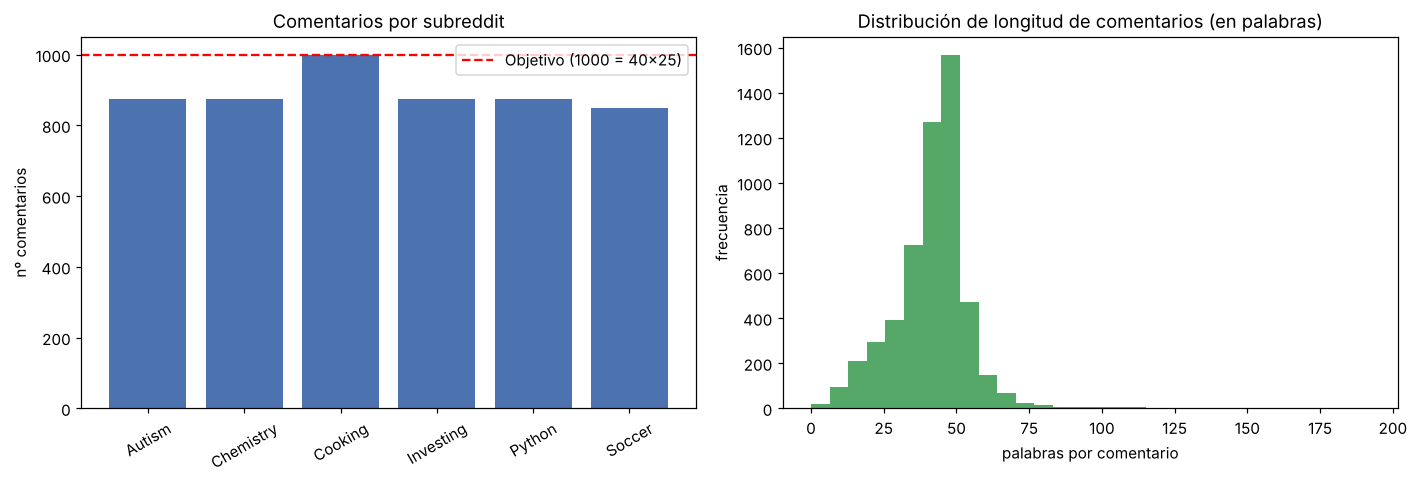

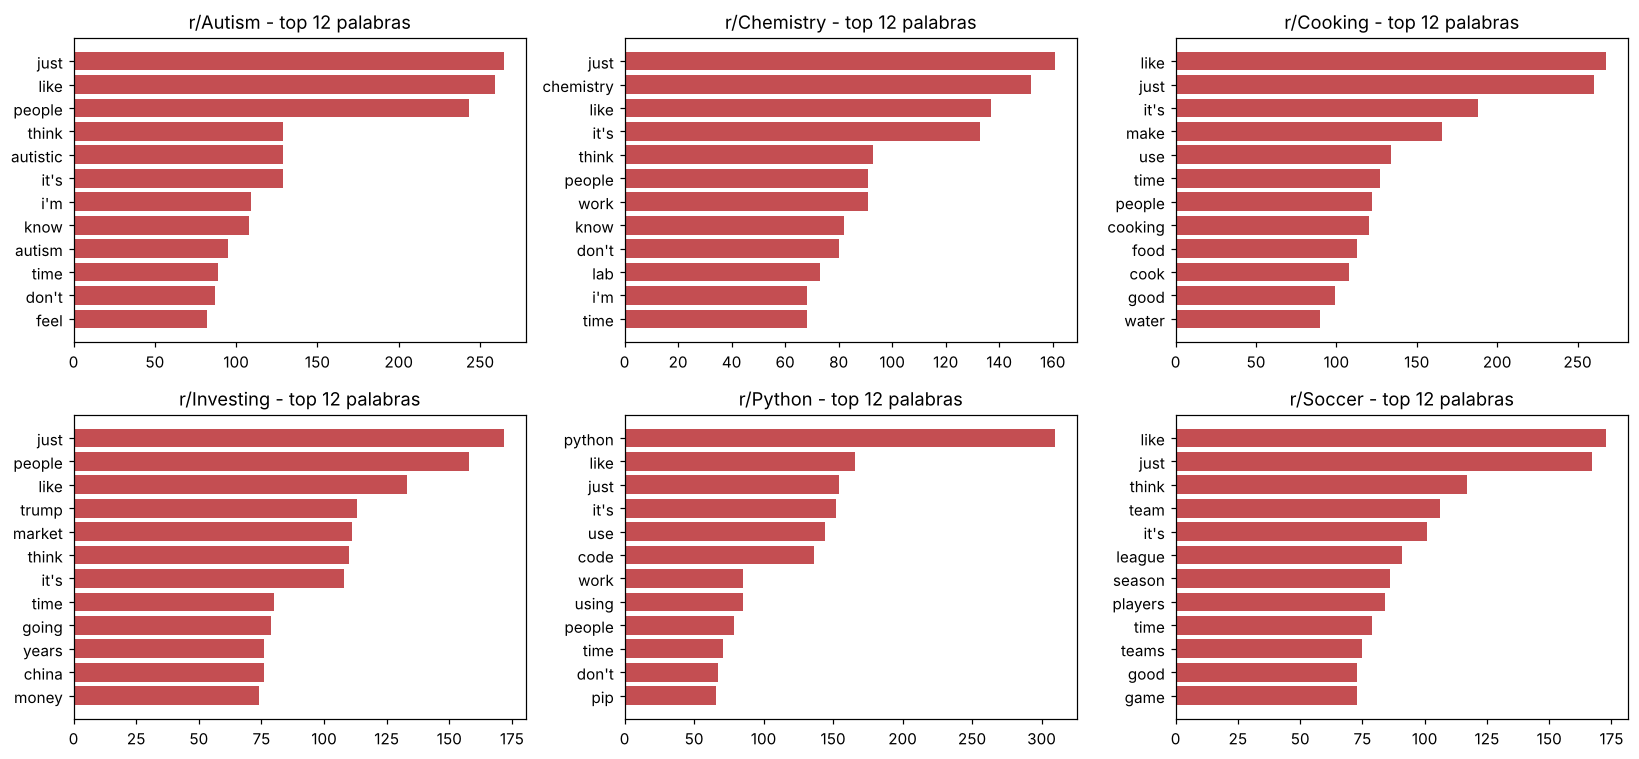

In [1]:
import json
import re
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

SUBREDDITS = ['Autism', 'Chemistry', 'Cooking', 'Investing', 'Python', 'Soccer']
URL_RE = re.compile(r'https?://\S+|www\.\S+')
WORD_RE = re.compile(r"[A-Za-zÁÉÍÓÚÜÑáéíóúüñ']+")

rows = []
word_counter_by_sub = {}
all_comment_lengths = []

for name in SUBREDDITS:
    data = json.load(open(DATA_DIR / f'{name}_filtrado.json', encoding='utf-8'))
    submissions = data['submissions']

    sub_word_counts = []
    for s in submissions:
        text = f"{s.get('title','')} {s.get('selftext','')}"
        sub_word_counts.append(len(WORD_RE.findall(text)))

    comment_word_counts = []
    comment_char_counts = []
    counter = Counter()
    for s in submissions:
        for c in s.get('comments', []):
            body = c.get('body', '') or ''
            body_clean = URL_RE.sub(' ', body)
            words = WORD_RE.findall(body_clean)
            comment_word_counts.append(len(words))
            comment_char_counts.append(len(body))
            all_comment_lengths.append(len(words))
            for w in words:
                wl = w.lower()
                if wl not in ENGLISH_STOP_WORDS and len(wl) > 2:
                    counter[wl] += 1

    word_counter_by_sub[name] = counter

    rows.append({
        'subreddit': name,
        'num_submissions': data['num_submissions'],
        'num_comments': data['total_comments'],
        'avg_words_per_submission': round(sum(sub_word_counts) / len(sub_word_counts), 1),
        'avg_words_per_comment': round(sum(comment_word_counts) / len(comment_word_counts), 1),
        'avg_chars_per_comment': round(sum(comment_char_counts) / len(comment_char_counts), 1),
    })

stats_df = pd.DataFrame(rows)
print("=" * 78)
print("ESTADÍSTICAS DEL CORPUS (palabras/caracteres), por subreddit")
print("=" * 78)
print(stats_df.to_string(index=False))

total_comments = stats_df['num_comments'].sum()
target_comments = 6 * 40 * 25
print(f"\nTotal de comentarios del corpus: {total_comments}")
print(f"Objetivo recomendado en el enunciado (6 subreddits x 40 hilos x 25 "
      f"comentarios): {target_comments}")
print(f"Déficit: {target_comments - total_comments} comentarios "
      f"({(target_comments - total_comments) / target_comments * 100:.1f}% por debajo del objetivo)")
print("\n(Esto confirma el punto señalado en la corrección: el corpus se queda "
      "corto respecto al mínimo recomendado. No se puede corregir aquí porque "
      "no tenemos acceso a los volcados originales RS_2025.zst / RC_2025.zst "
      "(>60GB) en este entorno; ver scripts/00_descarga_datos.py, que ya "
      "relaja los filtros de longitud para intentar recuperar más comentarios "
      "válidos por hilo la próxima vez que se ejecute con los datos crudos.)")

# --- Gráfica 1: nº de comentarios por subreddit (barras) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(stats_df['subreddit'], stats_df['num_comments'], color='#4C72B0')
axes[0].axhline(25 * 40, color='red', linestyle='--', label='Objetivo (1000 = 40x25)')
axes[0].set_title('Comentarios por subreddit')
axes[0].set_ylabel('nº comentarios')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

axes[1].hist(all_comment_lengths, bins=30, color='#55A868')
axes[1].set_title('Distribución de longitud de comentarios (en palabras)')
axes[1].set_xlabel('palabras por comentario')
axes[1].set_ylabel('frecuencia')
plt.tight_layout()
plt.show()

# --- Gráfica 2: palabras más frecuentes por subreddit (sustituye a la nube de palabras) ---
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, name in zip(axes.flat, SUBREDDITS):
    top = word_counter_by_sub[name].most_common(12)
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color='#C44E52')
    ax.set_title(f'r/{name} - top 12 palabras')
plt.tight_layout()
plt.show()
